In [58]:
import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from collections import Counter




plt.rc('font', family='Malgun Gothic')
plt.rc('axes', unicode_minus=False)

# 1. 데이터 로드 + 기본 탐색 + 파생변수 생성

In [59]:
df = pd.read_csv('./data/reviews_joined_all_matched.csv')

C:\Users\user\AppData\Local\Temp\ipykernel_35460\1931989018.py:1: DtypeWarning: Columns (22) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('./data/reviews_joined_all_matched.csv')


In [60]:
df.columns

Index(['appid', 'recommendationid', 'steamid', 'num_games_owned',
       'num_reviews_author', 'playtime_forever', 'playtime_last_two_weeks',
       'playtime_at_review', 'deck_playtime_at_review', 'last_played',
       'language', 'review', 'timestamp_created', 'timestamp_updated',
       'voted_up', 'votes_up', 'votes_funny', 'weighted_vote_score',
       'comment_count', 'steam_purchase', 'received_for_free',
       'written_during_early_access', 'developer_response',
       'timestamp_dev_responded', 'primarily_steam_deck', 'appid_1',
       'game_name', 'genre'],
      dtype='object')

In [61]:
df[['genre']]

,genre
0,"['Action', 'Adventure', 'RPG', 'Simulation', '..."
1,"['Action', 'Adventure', 'RPG', 'Simulation', '..."
2,"['Action', 'Adventure', 'RPG', 'Simulation', '..."
3,"['Action', 'Adventure', 'RPG', 'Simulation', '..."
4,"['Action', 'Adventure', 'RPG', 'Simulation', '..."
...,...
1030651,"['Adventure', 'Indie', 'Simulation', 'Strategy']"
1030652,"['Adventure', 'Indie', 'Simulation', 'Strategy']"
1030653,"['Adventure', 'Indie', 'Simulation', 'Strategy']"
1030654,"['Adventure', 'Indie', 'Simulation', 'Strategy']"


In [62]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1030656 entries, 0 to 1030655
Data columns (total 28 columns):
 #   Column                       Non-Null Count    Dtype  
---  ------                       --------------    -----  
 0   appid                        1030656 non-null  int64  
 1   recommendationid             1030656 non-null  int64  
 2   steamid                      1030656 non-null  int64  
 3   num_games_owned              1030656 non-null  int64  
 4   num_reviews_author           1030656 non-null  int64  
 5   playtime_forever             1030645 non-null  float64
 6   playtime_last_two_weeks      1030645 non-null  float64
 7   playtime_at_review           1030656 non-null  int64  
 8   deck_playtime_at_review      19544 non-null    float64
 9   last_played                  1030645 non-null  float64
 10  language                     1030656 non-null  object 
 11  review                       1027088 non-null  object 
 12  timestamp_created            1030656 non-n

In [63]:
df.loc[0]

appid                                                                    2139460
recommendationid                                                       199685023
steamid                                                        76561198220582271
num_games_owned                                                               23
num_reviews_author                                                             1
playtime_forever                                                         15240.0
playtime_last_two_weeks                                                      0.0
playtime_at_review                                                         15240
deck_playtime_at_review                                                      NaN
last_played                                                         1748034106.0
language                                                                 turkish
review                         oyunu kurduk eyv oynadık vs zaten türk ü bırak...
timestamp_created           

In [64]:
df.isna().sum()

appid                                0
recommendationid                     0
steamid                              0
num_games_owned                      0
num_reviews_author                   0
playtime_forever                    11
playtime_last_two_weeks             11
playtime_at_review                   0
deck_playtime_at_review        1011112
last_played                         11
language                             0
review                            3568
timestamp_created                    0
timestamp_updated                    0
voted_up                             0
votes_up                             0
votes_funny                          0
weighted_vote_score                  0
comment_count                        0
steam_purchase                       0
received_for_free                    0
written_during_early_access          0
developer_response             1027150
timestamp_dev_responded        1027150
primarily_steam_deck                 0
appid_1                  

In [65]:
df.describe()

,appid,recommendationid,steamid,num_games_owned,num_reviews_author,playtime_forever,playtime_last_two_weeks,playtime_at_review,deck_playtime_at_review,last_played,timestamp_created,timestamp_updated,votes_up,votes_funny,weighted_vote_score,comment_count,timestamp_dev_responded,appid_1
count,1.030656e+06,1.030656e+06,1.030656e+06,1.030656e+06,1.030656e+06,1.030645e+06,1.030645e+06,1.030656e+06,19544.000000,1.030645e+06,1.030656e+06,1.030656e+06,1.030656e+06,1.030656e+06,1.030656e+06,1.030656e+06,3.506000e+03,1.030656e+06
mean,1.246007e+06,2.078202e+08,7.656120e+16,5.589029e+01,9.407134e+00,1.421312e+04,4.750142e+02,1.179464e+04,1883.487055,1.762456e+09,1.760941e+09,1.761054e+09,6.485481e-01,1.244169e-01,5.027320e-01,4.645294e-02,1.759162e+09,1.246007e+06
std,8.606580e+05,4.897537e+06,6.086190e+08,1.973416e+02,6.927022e+01,3.357524e+04,1.155320e+03,3.145326e+04,5554.090679,1.173887e+07,4.747926e+06,4.725906e+06,1.345458e+01,3.082606e+00,2.275669e-02,6.260744e-01,4.410209e+06,8.606580e+05
min,4.400000e+02,1.994023e+08,7.656120e+16,0.000000e+00,1.000000e+00,5.000000e+00,0.000000e+00,5.000000e+00,1.000000,1.345532e+09,1.752096e+09,1.752096e+09,0.000000e+00,0.000000e+00,1.352486e-01,0.000000e+00,1.752181e+09,4.400000e+02
25%,5.268700e+05,2.032641e+08,7.656120e+16,0.000000e+00,1.000000e+00,1.440000e+03,0.000000e+00,8.080000e+02,46.000000,1.761593e+09,1.756657e+09,1.756828e+09,0.000000e+00,0.000000e+00,5.000000e-01,0.000000e+00,1.755116e+09,5.268700e+05
50%,1.172470e+06,2.081491e+08,7.656120e+16,0.000000e+00,3.000000e+00,4.408000e+03,0.000000e+00,2.723000e+03,276.000000,1.765687e+09,1.762017e+09,1.762260e+09,0.000000e+00,0.000000e+00,5.000000e-01,0.000000e+00,1.759032e+09,1.172470e+06
75%,1.771300e+06,2.122663e+08,7.656120e+16,5.100000e+01,8.000000e+00,1.229500e+04,3.620000e+02,9.001000e+03,1462.000000,1.767210e+09,1.764576e+09,1.764617e+09,0.000000e+00,0.000000e+00,5.000000e-01,0.000000e+00,1.763067e+09,1.771300e+06
max,3.241660e+06,2.152632e+08,7.656120e+16,3.370000e+04,1.974800e+04,2.457680e+06,3.460800e+04,2.416117e+06,157407.000000,1.767652e+09,1.767650e+09,1.767651e+09,5.763000e+03,1.425000e+03,9.897801e-01,2.580000e+02,1.767650e+09,3.241660e+06


In [66]:
# 결측치 비율(상위 20개만)
na_rate = (df.isna().mean().sort_values(ascending=False) * 100).round(2)
print("\n결측치 비율(%) TOP20")
print(na_rate.head(20))


결측치 비율(%) TOP20
timestamp_dev_responded    99.66
developer_response         99.66
deck_playtime_at_review    98.10
review                      0.35
last_played                 0.00
playtime_forever            0.00
playtime_last_two_weeks     0.00
steamid                     0.00
num_games_owned             0.00
num_reviews_author          0.00
recommendationid            0.00
appid                       0.00
language                    0.00
playtime_at_review          0.00
timestamp_created           0.00
timestamp_updated           0.00
votes_funny                 0.00
weighted_vote_score         0.00
voted_up                    0.00
votes_up                    0.00
dtype: float64


- 결측치 0으로 대체

In [67]:
df['playtime_forever'] = df['playtime_forever'].fillna(0)
df['playtime_last_two_weeks'] = df['playtime_last_two_weeks'].fillna(0)
df['deck_playtime_at_review'] = df['deck_playtime_at_review'].fillna(0)
df['last_played'] = df['last_played'].fillna(0)
df['review'] = df['review'].fillna('N')
df['developer_response'] = df['developer_response'].fillna('N')
df['timestamp_dev_responded'] = df['timestamp_dev_responded'].fillna(0)

In [68]:
# 중복 행 개수
print("\n중복 행 개수:", df.duplicated().sum())


중복 행 개수: 0


### game_stlye 매핑 + none 기본값

In [69]:
# 29개만 우선 매핑 (나머지는 none)
STYLE_MAP = {
    578080:  "online",  # PUBG
    3241660: "online",  # R.E.P.O.
    1174180: "video",   # RDR2
    236390:  "online",  # War Thunder
    413150:  "video",   # Stardew Valley
    1091500: "story",   # Cyberpunk 2077
    381210:  "online",  # Dead by Daylight (오타 onling -> online로 처리)
    1245620: "video",   # Elden Ring
    1172470: "online",  # Apex
    1551360: "video",   # Forza Horizon 5
    2183900: "story",   # Space Marine AE
    2139460: "online",  # Once Human
    2001120: "story",   # Split Fiction
    1973530: "online",  # Limbus Company
    1426210: "story",   # It Takes Two
    526870:  "video",   # Satisfactory
    1086940: "video",   # BG3
    294100:  "video",   # RimWorld
    1771300: "video",   # Kingdom Come 2
    2246340: "video",   # Monster Hunter Wilds
    1142710: "video",   # Total War WH3
    648800:  "video",   # Raft
    261550:  "video",   # Mount & Blade: Warband
    1966720: "online",  # Lethal Company
    1222670: "video",   # The Sims 4
    1203620: "video",   # Enshrouded
    1627720: "story",   # Lies of P
    1868140: "story",   # DAVE THE DIVER
    2651280: "story",   # Spider-Man 2
}

# game_style 컬럼 생성 (기본 none)
df["game_style"] = df["appid"].map(STYLE_MAP).fillna("none")


### Game Style 나눈 장르로 churn 생성

In [70]:
mask_known = df["game_style"].fillna("none").ne("none")
print("known(game_style!=none) 행 수:", mask_known.sum())
print("none 행 수:", (~mask_known).sum())


known(game_style!=none) 행 수: 961107
none 행 수: 69549


In [71]:
# churn 라벨 생성 (2조건 버전) 
# - game_style == none 은 churn 계산 제외 (NaN)
# - 조건1: 리뷰 후 churn_thr 일 이내에 마지막 플레이(=떠난 후보)
# - 조건2: 마지막 플레이 이후 관측 종료 시점까지 churn_thr 일 이상 관측됨(=복귀 없다고 볼 기간 확보)

mask_known = df["game_style"].fillna("none").ne("none")

review_dt = pd.to_datetime(df["timestamp_created"], unit="s", errors="coerce")
last_dt   = pd.to_datetime(df["last_played"], unit="s", errors="coerce")

df["days_after_review"] = (last_dt - review_dt).dt.days

THRESH_MAP = {"online": 14, "video": 30, "story": 10}

# threshold: known에만
df.loc[mask_known, "churn_thr"] = (
    df.loc[mask_known, "game_style"]
      .map(THRESH_MAP)
      .astype(int)
)

# 관측 종료 시점(obs_end) 잡기: timestamp_updated가 있으면 우선 사용
if "timestamp_updated" in df.columns:
    obs_end_dt = pd.to_datetime(df["timestamp_updated"], unit="s", errors="coerce").max()
else:
    obs_end_dt = pd.NaT

# fallback
if pd.isna(obs_end_dt):
    obs_end_dt = review_dt.max()

# 조건1: 리뷰 이후 thr일 안에 마지막 플레이(=떠난 후보)
cond_early = (df["days_after_review"] < df["churn_thr"])

# 조건2: 마지막 플레이 이후 obs_end까지 thr일 이상 관측됨(=복귀 없다고 볼 기간 확보)
days_since_last = (obs_end_dt - last_dt).dt.days
cond_no_return = (days_since_last >= df["churn_thr"])

# churn: known에만
df.loc[mask_known, "churn"] = (cond_early & cond_no_return).astype(int)

# 예외(known에만): last_played가 0/결측이거나, days_after_review가 음수면 churn=1
df.loc[mask_known & (df["last_played"].fillna(0).astype(float) == 0), "churn"] = 1
df.loc[mask_known & (df["days_after_review"].fillna(-1) < 0), "churn"] = 1

# none은 churn NaN
df.loc[~mask_known, "churn"] = np.nan

df_all = df.copy()  # 전체 보관 (분포/분석용)

df_model = df_all.loc[mask_known].copy()
df_model = df_model.dropna(subset=["churn"]).copy()
df_model["churn"] = df_model["churn"].astype(int)

print("obs_end_dt:", obs_end_dt)
print("df_all rows:", len(df_all), " / df_model rows:", len(df_model))
print("df_model churn 분포:\n", df_model["churn"].value_counts(dropna=False))
print("df_model game_style 분포:\n", df_model["game_style"].value_counts(dropna=False))
print("known만 이탈률(%) =", round(df_model["churn"].mean() * 100, 2))

obs_end_dt: 2026-01-05 22:16:22
df_all rows: 1030656  / df_model rows: 961107
df_model churn 분포:
 churn
0    617114
1    343993
Name: count, dtype: int64
df_model game_style 분포:
 game_style
online    401636
video     388425
story     171046
Name: count, dtype: int64
known만 이탈률(%) = 35.79


### df_model 만든 다음에 int로 변환

In [72]:
# 1) churn / game_style 만든 뒤 (none -> churn NaN 상태)
# 2) 학습용 df_model로 known만 남기기
# df_model = df[df["game_style"] != "none"].copy()

# # 혹시라도 예외로 churn NaN이 남아있으면 제거(안전장치)
# df_model = df_model.dropna(subset=["churn"]).copy()

# # 3) 이제 df_model에서만 int 변환
# for c in ["churn", "is_ending_genre", "good_review"]:
#     if c in df_model.columns:
#         df_model[c] = df_model[c].astype(int)

# print("df_model rows:", len(df_model))
# print("churn NaN in df_model:", df_model["churn"].isna().sum())
# print(df_model["churn"].value_counts())


In [73]:
# df_model = df.loc[mask_known].copy()

# print("df_model shape:", df_model.shape)
# print("df_model game_style 분포")
# print(df_model["game_style"].value_counts())
# print("df_model churn 분포")
# print(df_model["churn"].value_counts())


In [74]:
TOP_N_APPS = 30
top_appids = (
    df_model.groupby("appid")
    .size()
    .sort_values(ascending=False)
    .head(TOP_N_APPS)
    .index
    .tolist()
)

print("상위 appid 수:", len(top_appids))
print(top_appids[:10])


상위 appid 수: 29
[578080, 3241660, 1174180, 236390, 413150, 1091500, 381210, 1245620, 1172470, 1551360]


In [75]:
# review_dt = pd.to_datetime(df["timestamp_created"], unit="s", errors="coerce")
# last_dt   = pd.to_datetime(df["last_played"], unit="s", errors="coerce")

# df["days_after_review"] = (last_dt - review_dt).dt.days


# # game_style별 기준일
# THRESH_MAP = {
#     "online": 7,
#     "video": 30,
#     "story": 5,
#     "none": 7   # 분류 못한 게임은 일단 7일(원하면 30 등으로 바꿔도 됨)
# }

# # 각 행마다 사용할 threshold (없으면 none 처리)
# df["churn_thr"] = df["game_style"].fillna("none").map(THRESH_MAP).fillna(7).astype(int)

# # churn 정의: "리뷰 후 threshold 일 이내에 마지막 플레이가 있었다" => churn=1
# df["churn"] = (df["days_after_review"] < df["churn_thr"]).astype(int)

# # 예외 처리(기존 로직 유지)
# df.loc[df["last_played"].fillna(0).astype(float) == 0, "churn"] = 1
# df.loc[df["days_after_review"].fillna(-1) < 0, "churn"] = 1

### 전체 분포 + 스타일별 분포 확인

In [76]:
print(df["churn"].value_counts(dropna=False))
print("전체 이탈률(%) =", round(df["churn"].mean() * 100, 2))

print("\n[game_style별] 건수/이탈률")
display(
    df.groupby("game_style")["churn"]
      .agg(개수="count", 이탈률="mean")
      .assign(이탈률퍼센트=lambda x: (x["이탈률"]*100).round(2))
      .sort_values("개수", ascending=False)
)

df[["game_style","timestamp_created","last_played","days_after_review","churn_thr","churn"]].head(10)


churn
0.0    617114
1.0    343993
NaN     69549
Name: count, dtype: int64
전체 이탈률(%) = 35.79

[game_style별] 건수/이탈률


,개수,이탈률,이탈률퍼센트
game_style,,,
online,401636,0.303631,30.36
video,388425,0.361856,36.19
story,171046,0.476422,47.64
none,0,NaN,NaN


,game_style,timestamp_created,last_played,days_after_review,churn_thr,churn
0,online,1752389967,1.748034e+09,-51,14.0,1.0
1,online,1752389691,1.755746e+09,38,14.0,0.0
2,online,1752389204,1.755124e+09,31,14.0,0.0
3,online,1752388914,1.755366e+09,34,14.0,0.0
4,online,1752388911,1.752985e+09,6,14.0,1.0
5,online,1752388910,1.766829e+09,167,14.0,0.0
6,online,1752388876,1.766576e+09,164,14.0,0.0
7,online,1752388776,1.766982e+09,168,14.0,0.0
8,online,1752388170,1.752628e+09,2,14.0,1.0
9,online,1752388029,1.755831e+09,39,14.0,0.0


- 타겟 변수 churn 생성

In [77]:
# review_dt = pd.to_datetime(df["timestamp_created"], unit="s")
# last_dt   = pd.to_datetime(df["last_played"], unit="s")

# df["days_after_review"] = (last_dt - review_dt).dt.days

# df["churn"] = (df["days_after_review"] < 7).astype(int)

# # 예외 처리
# df.loc[df["last_played"] == 0, "churn"] = 1
# df.loc[df["days_after_review"] < 0, "churn"] = 1

# # 분포 확인
# print(df["churn"].value_counts(dropna=False))
# print("이탈률(%) =", round(df["churn"].mean() * 100, 2))
# df[["timestamp_created","last_played","days_after_review","churn"]].head(5)

- 장르 기반 파생변수 is_ending_genre 생성

In [78]:
ending_genre = [
  "Visual Novel",
  "Interactive Fiction",
  "Walking Simulator",
  "Story Rich",
  "Adventure",
  "Puzzle",
  "Horror",
  "Mystery",
  "Psychological Horror",
  "Narrative"
]

genre_col = "genre"

# 포함 여부(부분일치) - df_model에만 생성 (학습용)
pattern = "|".join(ending_genre)

df_model["is_ending_genre"] = (
    df_model[genre_col]
      .fillna("")
      .astype(str)
      .str.contains(pattern, regex=True)
      .astype(int)
)

print(df_model["is_ending_genre"].value_counts())
print("클리어형 추정 비율(%) =", round(df_model["is_ending_genre"].mean() * 100, 2))


is_ending_genre
1    500015
0    461092
Name: count, dtype: int64
클리어형 추정 비율(%) = 52.02


In [79]:
print("총 appid 개수(df 기준):", df["appid"].nunique())
print(df["game_style"].value_counts())

# none에 해당하는 appid 몇 개인지 보기
none_appids = df.loc[df["game_style"] == "none", "appid"].unique()
print("\nnone appid 개수:", len(none_appids))
print("none appid 샘플(최대 20개):", none_appids[:20])


총 appid 개수(df 기준): 63
game_style
online    401636
video     388425
story     171046
none       69549
Name: count, dtype: int64

none appid 개수: 34
none appid 샘플(최대 20개): [ 960170 1049590 2344520     730 1623730 3240220  216150 2426960  985810
  553850 1158310 1144200 2215430 1222140  934700     570 1145350  108600
     440  990080]


- good_review 생성

In [80]:
# 1) 언어별 키워드 사전
# - phrases: 문장/구문(부분일치 OK)
# - words: 단어성 키워드(라틴권은 단어경계 \b 적용)
# - neg: 부정 구문(걸리면 good=0으로 처리)
# - boundary: words에 \b를 붙일지 여부 (중국어/일본어/태국어/한국어는 보통 False)
LEXICON = {
    # English
    "english": {
        "phrases": [
            r"highly recommend(?:ed)?",
            r"definitely recommend",
            r"worth (?:buying|it|the money|the time)",
            r"great game",
            r"amazing game",
            r"awesome game",
            r"best game(?:s)?",
        ],
        "words": [
            r"awesome", r"amazing", r"great", r"excellent", r"fantastic", r"incredible",
            r"masterpiece", r"perfect", r"love", r"fun", r"enjoy", r"recommend", r"worth",
        ],
        "neg": [
            r"not\s+good", r"not\s+great", r"not\s+worth",
            r"(?:do\s*not|don't|dont)\s+recommend",
            r"(?:do\s*not|don't|dont)\s+buy",
            r"can't\s+recommend|cant\s+recommend",
            r"avoid\b", r"refund\b",
        ],
        "boundary": True,
    },

    # Spanish (Spain) + LatAm는 같이 처리
    "spanish": {
        "phrases": [r"muy bueno", r"vale la pena", r"lo recomiendo", r"recomendad[oa]"],
        "words": [r"genial", r"excelente", r"buen[oa]", r"incre[ií]ble", r"recomiendo", r"recomendar"],
        "neg": [r"no\s+recomiendo", r"no\s+vale\s+la\s+pena", r"no\s+es\s+buen[oa]", r"no\s+merece\s+la\s+pena", r"no\s+compr(?:es|ar)"],
        "boundary": True,
    },
    "latam": {  # 라틴아메리카 스페인어
        "phrases": [r"muy bueno", r"vale la pena", r"lo recomiendo", r"recomendad[oa]"],
        "words": [r"genial", r"excelente", r"buen[oa]", r"incre[ií]ble", r"recomiendo", r"recomendar"],
        "neg": [r"no\s+recomiendo", r"no\s+vale\s+la\s+pena", r"no\s+es\s+buen[oa]", r"no\s+merece\s+la\s+pena", r"no\s+compr(?:es|ar)"],
        "boundary": True,
    },

    # Portuguese (PT / BR)
    "portuguese": {
        "phrases": [r"vale a pena", r"recomendo", r"muito bom", r"jogo (?:muito )?bom"],
        "words": [r"ótimo", r"excelente", r"incr[ií]vel", r"perfeito", r"divertido", r"recomendar"],
        "neg": [r"não\s+recomendo", r"nao\s+recomendo", r"não\s+vale\s+a\s+pena", r"nao\s+vale\s+a\s+pena", r"não\s+é\s+bom", r"nao\s+e\s+bom", r"não\s+compr(?:e|ar)", r"nao\s+compr(?:e|ar)"],
        "boundary": True,
    },
    "brazilian": {  # 브라질 포르투갈어
        "phrases": [r"vale a pena", r"recomendo", r"muito bom", r"jogo (?:muito )?bom"],
        "words": [r"ótimo", r"excelente", r"incr[ií]vel", r"perfeito", r"divertido", r"recomendar"],
        "neg": [r"não\s+recomendo", r"nao\s+recomendo", r"não\s+vale\s+a\s+pena", r"nao\s+vale\s+a\s+pena", r"não\s+é\s+bom", r"nao\s+e\s+bom", r"não\s+compr(?:e|ar)", r"nao\s+compr(?:e|ar)"],
        "boundary": True,
    },

    # German
    "german": {
        "phrases": [r"sehr gut", r"klare(?:s)? empfehlung", r"lohnt sich", r"absolut empfehl"],
        "words": [r"genial", r"toll", r"super", r"großartig", r"exzellent", r"empfehle", r"empfehlenswert"],
        "neg": [r"nicht\s+empfehl", r"lohnt\s+sich\s+nicht", r"nicht\s+gut", r"kau(?:f|ft)\s+nicht", r"kein\s+kauf"],
        "boundary": True,
    },

    # French
    "french": {
        "phrases": [r"je recommande", r"vaut le coup", r"tr[eè]s bon", r"excellent jeu"],
        "words": [r"g[eé]nial", r"excellent", r"super", r"incroyable", r"parfait", r"recommande"],
        "neg": [r"je\s+ne\s+recommande\s+pas", r"ne\s+vaut\s+pas\s+le\s+coup", r"pas\s+bon", r"n['’]achetez\s+pas", r"n['’]ach[eè]te\s+pas"],
        "boundary": True,
    },

    # Italian
    "italian": {
        "phrases": [r"lo consiglio", r"vale la pena", r"molto bello", r"gioco (?:molto )?bello"],
        "words": [r"fantastico", r"ottimo", r"eccellente", r"stupendo", r"divertente", r"consiglio", r"consigliare"],
        "neg": [r"non\s+lo\s+consiglio", r"non\s+vale\s+la\s+pena", r"non\s+[eè]\s+bello", r"non\s+compr(?:are|atelo)"],
        "boundary": True,
    },

    # Dutch
    "dutch": {
        "phrases": [r"zeker aanraden", r"de moeite waard", r"heel goed", r"geweldig spel"],
        "words": [r"geweldig", r"fantastisch", r"super", r"leuk", r"aanraden", r"aanbevelen", r"waarde"],
        "neg": [r"niet\s+aanrad", r"niet\s+de\s+moeite\s+waard", r"niet\s+goed", r"koop\s+niet"],
        "boundary": True,
    },

    # Swedish / Norwegian / Danish / Finnish
    "swedish": {
        "phrases": [r"rekommenderar", r"värt det", r"jättebra", r"riktigt bra"],
        "words": [r"fantastisk", r"grym", r"suverän", r"toppen", r"kul", r"rekommendera", r"värd"],
        "neg": [r"rekommenderar\s+inte", r"inte\s+värt", r"inte\s+bra", r"köp\s+inte"],
        "boundary": True,
    },
    "norwegian": {
        "phrases": [r"anbefaler", r"verdt det", r"kjempebra", r"veldig bra"],
        "words": [r"fantastisk", r"råbra", r"suveren", r"gøy", r"anbefale", r"verdt"],
        "neg": [r"anbefaler\s+ikke", r"ikke\s+verdt", r"ikke\s+bra", r"ikke\s+kjøp"],
        "boundary": True,
    },
    "danish": {
        "phrases": [r"anbefaler", r"v[æa]rd at", r"mega god", r"rigtig god"],
        "words": [r"fantastisk", r"fremragende", r"super", r"sjov", r"anbefale", r"v[æa]rd"],
        "neg": [r"anbefaler\s+ikke", r"ikke\s+v[æa]rd", r"ikke\s+god", r"k[oø]b\s+ikke"],
        "boundary": True,
    },
    "finnish": {
        "phrases": [r"suosittelen", r"todella hyv[äa]", r"sen arvoinen", r"hyv[äa] peli"],
        "words": [r"loistava", r"mahtava", r"erinomainen", r"hauska", r"suositella", r"arvoinen"],
        "neg": [r"en\s+suosittele", r"ei\s+kannata", r"ei\s+hyv[äa]", r"älä\s+osta"],
        "boundary": True,
    },

    # Polish / Czech / Romanian / Hungarian / Bulgarian / Greek / Ukrainian / Russian / Turkish
    "polish": {
        "phrases": [r"polecam", r"warto", r"świetna gra", r"bardzo dobra"],
        "words": [r"świetn[aey]", r"super", r"rewelacyjna", r"doskonała", r"polecić", r"warto"],
        "neg": [r"nie\s+polecam", r"nie\s+warto", r"nie\s+jest\s+dobr", r"nie\s+kupuj"],
        "boundary": True,
    },
    "czech": {
        "phrases": [r"doporu[čc]uji", r"stoj[ií]\s+za\s+to", r"skv[ěe]l[aá]", r"v[ýy]born[aá]"],
        "words": [r"super", r"skv[ěe]l", r"v[ýy]born", r"bav[ií]", r"doporu[čc]it"],
        "neg": [r"nedoporu[čc]uji", r"nestoj[ií]\s+za\s+to", r"nen[ií]\s+dobr", r"nekupuj"],
        "boundary": True,
    },
    "romanian": {
        "phrases": [r"recomand", r"merit[ăa]", r"foarte bun", r"joc (?:foarte )?bun"],
        "words": [r"excelent", r"minunat", r"super", r"recomanda", r"merit"],
        "neg": [r"nu\s+recomand", r"nu\s+merit[ăa]", r"nu\s+e\s+bun", r"nu\s+cump[ăa]ra"],
        "boundary": True,
    },
    "hungarian": {
        "phrases": [r"aj[aá]nlom", r"meg[eé]ri", r"nagyon j[oó]", r"szuper j[aá]t[eé]k"],
        "words": [r"szuper", r"fantasztikus", r"kiv[aá]l[oó]", r"nagyon", r"aj[aá]nlani", r"meg[eé]r"],
        "neg": [r"nem\s+aj[aá]nlom", r"nem\s+[eé]ri\s+meg", r"nem\s+j[oó]", r"ne\s+vedd\s+meg"],
        "boundary": True,
    },
    "bulgarian": {
        "phrases": [r"препоръч", r"много добра", r"страхотна", r"заслужава си"],
        "words": [r"страхот", r"отлич", r"супер", r"препоръч", r"шедьовър"],
        "neg": [r"не\s+препоръч", r"не\s+си\s+струва", r"не\s+е\s+доб", r"не\s+купувай"],
        "boundary": False,  # кир릴은 \b가 애매해서 단순부분일치로
    },
    "greek": {
        "phrases": [r"το\s+προτείν", r"αξίζει", r"πολύ\s+καλ", r"εξαιρετικ"],
        "words": [r"τέλει", r"φοβε", r"εξαιρετικ", r"καταπληκτικ", r"προτείν", r"αξίζ"],
        "neg": [r"δεν\s+προτείν", r"δεν\s+αξίζ", r"δεν\s+είναι\s+καλ", r"μην\s+αγοράσ"],
        "boundary": False,
    },
    "ukrainian": {
        "phrases": [r"рекоменд", r"дуже\s+хорош", r"варто", r"чудов"],
        "words": [r"відмін", r"класн", r"шедевр", r"рекоменд", r"варто"],
        "neg": [r"не\s+рекоменд", r"не\s+варто", r"не\s+хорош", r"не\s+купуй"],
        "boundary": False,
    },
    "russian": {
        "phrases": [r"рекоменд", r"очень\s+хорош", r"стоит", r"шедевр"],
        "words": [r"отлич", r"классн", r"супер", r"шедевр", r"рекоменд", r"стоит"],
        "neg": [r"не\s+рекоменд", r"не\s+стоит", r"плох", r"не\s+покупай", r"не\s+берите"],
        "boundary": False,
    },
    "turkish": {
        "phrases": [r"kesinlikle tavsiye", r"tavsiye ederim", r"çok iyi", r"mükemmel", r"harika"],
        "words": [r"güzel", r"mükemmel", r"harika", r"şahane", r"tavsiye", r"değer"],
        "neg": [r"tavsiye etmem", r"tavsiye etmiyorum", r"iyi değil", r"alma", r"almayın", r"değmez"],
        "boundary": True,
    },

    # Korean / Japanese / Chinese / Arabic / Thai / Vietnamese / Indonesian
    "koreana": {
        "phrases": [r"강추", r"완전 추천", r"강력 추천", r"갓겜", r"명작", r"존잼", r"개꿀잼", r"재밌", r"재미있"],
        "words": [r"추천", r"최고", r"꿀잼", r"재미", r"좋다", r"훌륭", r"완벽", r"감동"],
        "neg": [r"비추", r"추천\s*안", r"추천\s*하지", r"재미없", r"별로", r"최악", r"사지\s*마", r"사지마", r"환불"],
        "boundary": False,
    },
    "japanese": {
        "phrases": [r"おすすめ", r"オススメ", r"最高", r"神ゲー", r"買う価値", r"面白い", r"楽しい"],
        "words": [r"おすすめ", r"最高", r"神", r"面白", r"楽しい", r"良い", r"素晴らしい"],
        "neg": [r"おすすめしない", r"買わない方が", r"つまらない", r"面白くない", r"最悪", r"返品"],
        "boundary": False,
    },
    "schinese": {
        "phrases": [r"强烈推荐", r"非常推荐", r"值得买", r"值得入", r"很值得", r"很好玩", r"神作", r"精品"],
        "words": [r"推荐", r"值得", r"好玩", r"很好", r"优秀", r"完美", r"喜欢"],
        "neg": [r"不推荐", r"不值得", r"不好玩", r"垃圾", r"别买", r"千万别买", r"退款"],
        "boundary": False,
    },
    "tchinese": {
        "phrases": [r"強烈推薦", r"非常推薦", r"值得買", r"值得入", r"很值得", r"很好玩", r"神作", r"精品"],
        "words": [r"推薦", r"值得", r"好玩", r"很好", r"優秀", r"完美", r"喜歡"],
        "neg": [r"不推薦", r"不值得", r"不好玩", r"垃圾", r"別買", r"千萬別買", r"退款"],
        "boundary": False,
    },
    "arabic": {
        "phrases": [r"أنصح", r"ممتاز", r"رائع", r"يستحق", r"لعبة رائعة", r"ممتعة"],
        "words": [r"ممتاز", r"رائع", r"جميل", r"ممتع", r"يستحق", r"أنصح"],
        "neg": [r"لا\s+أنصح", r"لا\s+يستحق", r"سيئ", r"لا\s+تشتري", r"استرجاع"],
        "boundary": False,
    },
    "thai": {
        "phrases": [r"แนะนำ", r"ดีมาก", r"สุดยอด", r"คุ้มค่า", r"สนุกมาก", r"โคตรสนุก"],
        "words": [r"แนะนำ", r"ดี", r"สนุก", r"สุดยอด", r"คุ้ม", r"ชอบ"],
        "neg": [r"ไม่แนะนำ", r"ไม่คุ้ม", r"ไม่ดี", r"แย่", r"อย่าซื้อ", r"ขอคืนเงิน"],
        "boundary": False,
    },
    "vietnamese": {
        "phrases": [r"rất hay", r"tuyệt vời", r"đáng mua", r"đáng tiền", r"nên mua", r"khuyên dùng"],
        "words": [r"hay", r"tuyệt", r"xuất sắc", r"đáng", r"thích", r"khuyên", r"nên"],
        "neg": [r"không\s+khuyên", r"không\s+đáng", r"đừng\s+mua", r"tệ", r"chán", r"hoàn tiền"],
        "boundary": True,
    },
    "indonesian": {
        "phrases": [r"sangat bagus", r"rekomendasi", r"worth it", r"layak dibeli", r"seru banget"],
        "words": [r"bagus", r"keren", r"mantap", r"seru", r"rekomend", r"layak"],
        "neg": [r"tidak\s+rekomend", r"jangan\s+beli", r"tidak\s+layak", r"jelek", r"buruk", r"refund"],
        "boundary": True,
    },
}

# 없는 언어는 english로 fallback
DEFAULT_LANG = "english"


# 2) 정규식 빌더
def _compile_lexicon(cfg):
    boundary = cfg.get("boundary", True)

    parts_good = []
    for p in cfg.get("phrases", []):
        parts_good.append(f"(?:{p})")
    for w in cfg.get("words", []):
        if boundary:
            parts_good.append(rf"\b{w}\b")
        else:
            parts_good.append(f"(?:{w})")

    good_pat = "|".join(parts_good) if parts_good else r"$^"
    good_re = re.compile(good_pat, flags=re.UNICODE)

    neg_parts = [f"(?:{p})" for p in cfg.get("neg", [])]
    neg_pat = "|".join(neg_parts) if neg_parts else r"$^"
    neg_re = re.compile(neg_pat, flags=re.UNICODE)

    return good_re, neg_re


_COMPILED = {}
for lang, cfg in LEXICON.items():
    _COMPILED[lang] = _compile_lexicon(cfg)
_COMPILED[DEFAULT_LANG] = _COMPILED.get(DEFAULT_LANG, _compile_lexicon(LEXICON["english"]))


def add_good_flag_multilang(df, text_col="review", lang_col="language"):
    out = df.copy()

    text = out[text_col].fillna("").astype(str).str.casefold()
    lang = out[lang_col].fillna(DEFAULT_LANG).astype(str)

    good_hit = pd.Series(False, index=out.index)
    neg_hit  = pd.Series(False, index=out.index)

    for l in lang.unique():
        mask = (lang == l)
        good_re, neg_re = _COMPILED.get(l, _COMPILED[DEFAULT_LANG])

        good_hit.loc[mask] = text.loc[mask].str.contains(good_re, regex=True)
        neg_hit.loc[mask]  = text.loc[mask].str.contains(neg_re,  regex=True)

    out["good_review"] = (good_hit & (~neg_hit)).astype(int)
    return out


# df_good = add_good_flag_multilang(df, text_col="review", lang_col="language")
# print(df_good["good_review"].value_counts())
df_model = add_good_flag_multilang(df_model, text_col="review", lang_col="language")
print(df_model["good_review"].value_counts())


good_review
0    702778
1    258329
Name: count, dtype: int64


In [81]:
# (is_ending_genre / good_review 생성 이후에 실행)
for c in ["is_ending_genre", "good_review"]:
    if c in df_model.columns:
        df_model[c] = pd.to_numeric(df_model[c], errors="coerce").fillna(0).astype(int)

# (혹시 churn도 다시 한번 안전하게)
df_model["churn"] = pd.to_numeric(df_model["churn"], errors="coerce")
df_model = df_model.dropna(subset=["churn"]).copy()
df_model["churn"] = df_model["churn"].astype(int)


### 새로운 파생변수 (민채/민정 작업)

In [102]:
# (파생변수 생성 셀) - df_model 기준
# 위치: is_ending_genre / good_review 생성 + 타입정리 후, SAFE_CANDIDATES 계산 전

import numpy as np
import pandas as pd

# 0) 필요한 컬럼 numeric 안전 변환
need_num = [
    "playtime_at_review",
    "num_games_owned",
    "num_reviews_author",
    "votes_up",
    "votes_funny",
    "comment_count",
    "weighted_vote_score",
    "good_review",
    "is_ending_genre",
]
for c in need_num:
    if c in df_model.columns:
        df_model[c] = pd.to_numeric(df_model[c], errors="coerce").fillna(0)

# 1) 비율/강도 피처
df_model["playtime_per_game"] = df_model["playtime_at_review"] / (df_model["num_games_owned"] + 1)
df_model["reviews_per_game"]  = df_model["num_reviews_author"] / (df_model["num_games_owned"] + 1)

# 2) 플레이 구간(임계값은 "고정값" 대신 데이터 기반으로 잡는 걸 추천)
#    - style별 분위기가 달라서, style별 분위수(q25/q75)로 구간을 잡으면 안정적임
q = (
    df_model.groupby("game_style")["playtime_at_review"]
    .quantile([0.25, 0.75])
    .unstack()
    .rename(columns={0.25: "q25", 0.75: "q75"})
)

df_model = df_model.join(q, on="game_style")

df_model["is_short_play"] = (df_model["playtime_at_review"] < df_model["q25"]).astype(int)
df_model["is_long_play"]  = (df_model["playtime_at_review"] >= df_model["q75"]).astype(int)
df_model["is_mid_play"]   = ((df_model["is_short_play"] == 0) & (df_model["is_long_play"] == 0)).astype(int)

# 3) heavy user (임계값은 일단 너 기준 유지, 나중에 조정 가능)
df_model["is_heavy_user"] = (
    (df_model["num_games_owned"] > 50) &
    (df_model["num_reviews_author"] > 10)
).astype(int)

# 4) 감정 × 행동 결합 (threshold는 style별 q25/q75 기반으로 잡으면 과도하게 임의적이지 않음)
# 4-1) 긍정인데 짧게 함 = 위험
df_model["positive_but_short_play"] = (
    (df_model["good_review"] == 1) &
    (df_model["playtime_at_review"] < df_model["q25"])
).astype(int)

# 4-2) 부정인데 오래 함 = 잔존 가능
df_model["negative_but_long_play"] = (
    (df_model["good_review"] == 0) &
    (df_model["playtime_at_review"] >= df_model["q75"])
).astype(int)

# 5) 사회적 반응
df_model["has_votes"]   = ((df_model["votes_up"] + df_model["votes_funny"]) > 0).astype(int)
df_model["has_comment"] = (df_model["comment_count"] > 0).astype(int)

# 6) 장르 × 행동 (엔딩장르 + 짧은 플레이)
df_model["ending_short_play"] = (
    (df_model["is_ending_genre"] == 1) &
    (df_model["playtime_at_review"] < df_model["q25"])
).astype(int)

# =============================================================================================
# 최근 활동 완전 단절 여부(2주 0시간 여부)
df_model['no_recent_play'] = (df_model["playtime_last_two_weeks"] == 0).astype(int)

# 플레이 감소 강도(최근/리뷰시점 대비 감소)
df_model['play_drop_ratio'] = 1 - (df_model['playtime_last_two_weeks'] / df_model['playtime_at_review'] + 1)

# 최근 활동성(최근2주/누적)
df_model['recent_ratio'] = df_model['playtime_last_two_weeks'] / (df_model['playtime_forever'] + 1)

# 플레이 강도(리뷰시점 플레이/보유게임수)
df_model['play_intensity'] = df_model['playtime_at_review'] / (df_model['num_games_owned'] + 1)
# =============================================================================================

# inf / -inf 안전 처리
df_model.replace([np.inf, -np.inf], 0, inplace=True)

# 임시로 붙인 분위수 컬럼은 모델 피처에서 제외하고 싶으면 지워도 됨(추천)
df_model.drop(columns=["q25", "q75"], inplace=True, errors="ignore")

print("파생변수 추가 완료. df_model shape:", df_model.shape)
df_model[[
    "playtime_per_game","reviews_per_game",
    "is_short_play","is_mid_play","is_long_play",
    "is_heavy_user","positive_but_short_play","negative_but_long_play",
    "has_votes","has_comment","ending_short_play",'no_recent_play','play_drop_ratio','recent_ratio','play_intensity'
]].head(3)


파생변수 추가 완료. df_model shape: (961107, 49)


,playtime_per_game,reviews_per_game,is_short_play,is_mid_play,is_long_play,is_heavy_user,positive_but_short_play,negative_but_long_play,has_votes,has_comment,ending_short_play,no_recent_play,play_drop_ratio,recent_ratio,play_intensity
0,3647.631318,0.165902,0,1,0,0,0,0,1,1,0,1,0.0,0.0,3647.631318
1,834.000000,0.693147,0,1,0,0,0,0,0,0,0,1,0.0,0.0,834.000000
2,12327.000000,0.693147,0,1,0,0,0,0,0,0,0,1,0.0,0.0,12327.000000


- df 갱신 및 새로 추가한 파생변수들 평균 확인

In [103]:
print("df_model 최종 컬럼 수:", df_model.shape[1])
print("churn 평균(이탈률):", round(df_model["churn"].mean(), 4))
print("is_ending_genre 평균:", round(df_model["is_ending_genre"].mean(), 4) if "is_ending_genre" in df_model.columns else "N/A")
print("good_review 평균:", round(df_model["good_review"].mean(), 4) if "good_review" in df_model.columns else "N/A")


df_model 최종 컬럼 수: 49
churn 평균(이탈률): 0.3579
is_ending_genre 평균: 0.5202
good_review 평균: 0.2688


# 2. 데이터 전처리

In [104]:
# boolean 컬럼이 있으면 0/1로 변환
bool_cols = df.select_dtypes(include=["bool"]).columns.tolist()
for c in bool_cols:
    df[c] = df[c].astype(int)

In [105]:
# target/파생 이진 컬럼은 확실히 int로
for c in ["churn", "is_ending_genre", "good_review"]:
    if c in df_model.columns:
        df_model[c] = pd.to_numeric(df_model[c], errors="coerce").fillna(0).astype(int)


In [86]:
# 숫자처럼 생겼는데 문자열인 컬럼들 안전 변환(실패하면 그대로 둠)
# maybe_num = ["votes_up", "votes_funny", "comment_count", "weighted_vote_score",
#              "playtime_forever", "num_games_owned", "num_reviews_author"]
# for c in maybe_num:
#     if c in df.columns:
#         df[c] = pd.to_numeric(df[c], errors="coerce").fillna(0)

# df.info()

- 누수 위험 컬럼들 정리

In [106]:
suspected_leaked_column = []

for c in [
    "last_played",
    "timestamp_created",
    "timestamp_updated",
    "timestamp_dev_responded",
    "days_after_review",
    "playtime_forever",
    "review",                 # 텍스트 원문 대신 good_review만 쓰기
    "developer_response"
]:
    if c in df_model.columns:
        suspected_leaked_column.append(c)

print("누수_의심_컬럼:", suspected_leaked_column)


누수_의심_컬럼: ['last_played', 'timestamp_created', 'timestamp_updated', 'timestamp_dev_responded', 'days_after_review', 'playtime_forever', 'review', 'developer_response']


- 모델용 데이터프레임 복사본 준비 -> 일단 보류(사용x)

In [88]:
# df_model = df.copy()

# 3. EDA 및 그래프 시각화

- 상관관계 히트맵

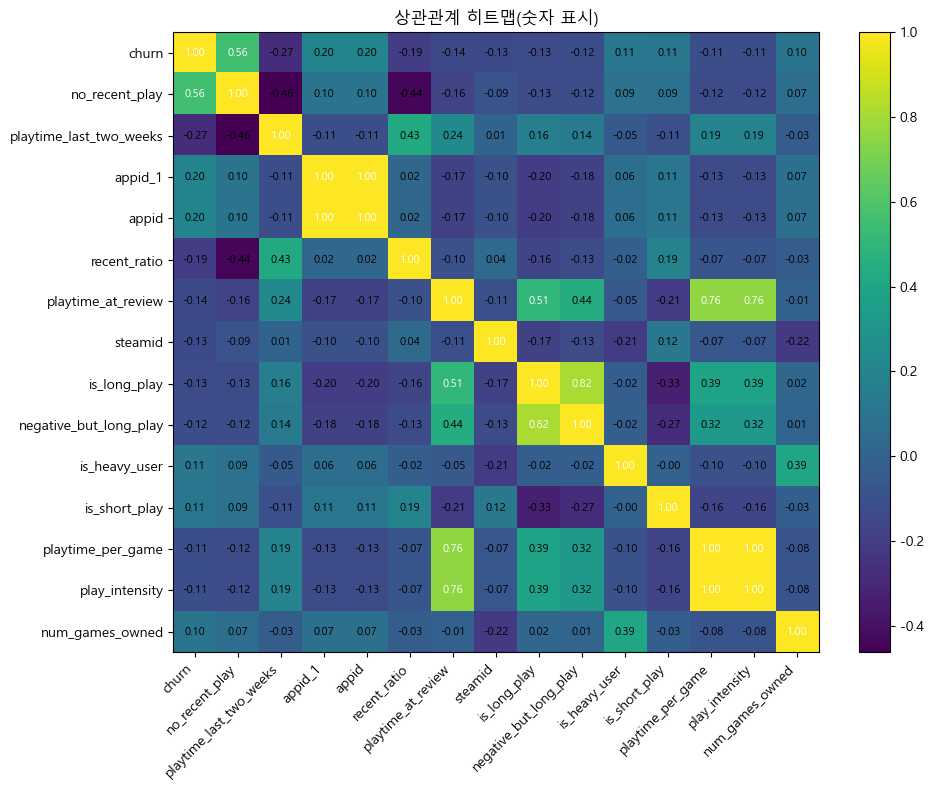


churn과 상관관계 TOP15


churn                 1.000000
no_recent_play        0.557100
appid_1               0.195569
appid                 0.195569
is_heavy_user         0.114751
is_short_play         0.112252
num_games_owned       0.097047
ending_short_play     0.073767
recommendationid      0.066215
num_reviews_author    0.050800
Name: churn, dtype: float64

playtime_last_two_weeks   -0.271594
recent_ratio              -0.194873
playtime_at_review        -0.140786
steamid                   -0.134746
is_long_play              -0.131241
negative_but_long_play    -0.116601
playtime_per_game         -0.112234
play_intensity            -0.112234
churn_thr                 -0.014353
weighted_vote_score       -0.008440
Name: churn, dtype: float64

In [89]:
# 숫자형만
num_df = df_model.drop(columns=suspected_leaked_column, errors="ignore").select_dtypes(include=[np.number]).copy()
corr = num_df.corr(numeric_only=True)

# churn과 상관 절댓값 상위 15개만 보기
top = corr["churn"].abs().sort_values(ascending=False).head(15).index
corr_top = corr.loc[top, top]

fig, ax = plt.subplots(figsize=(10, 8))

im = ax.imshow(corr_top.values, aspect="auto")
fig.colorbar(im, ax=ax)

ax.set_xticks(range(len(top)))
ax.set_yticks(range(len(top)))
ax.set_xticklabels(top, rotation=45, ha="right")
ax.set_yticklabels(top)

ax.set_title("상관관계 히트맵(숫자 표시)")

# 셀 안에 숫자 표시 (상관계수)
for i in range(corr_top.shape[0]):
    for j in range(corr_top.shape[1]):
        val = corr_top.iloc[i, j]
        # 배경색이 진하면 흰색, 연하면 검은색으로 글씨 보이게
        text_color = "white" if abs(val) > 0.5 else "black"
        ax.text(j, i, f"{val:.2f}", ha="center", va="center", color=text_color, fontsize=8)

plt.tight_layout()
plt.show()

print("\nchurn과 상관관계 TOP15")
display(corr["churn"].sort_values(ascending=False).head(10))
display(corr["churn"].sort_values(ascending=True).head(10))

- 카테고리 피처: 개수 + 이탈률 함수

In [90]:
def category_count_churn(df, col, top_n=10):
    tmp = df.copy()

    # 값이 너무 많으면 상위 top_n만, 나머지는 '기타'
    vc = tmp[col].astype(str).value_counts()
    if len(vc) > top_n:
        top_vals = vc.head(top_n).index
        tmp[col] = tmp[col].astype(str).where(tmp[col].astype(str).isin(top_vals), "기타")
    else:
        tmp[col] = tmp[col].astype(str)

    g = tmp.groupby(col)["churn"].agg(개수="count", 이탈률="mean").sort_values("개수", ascending=False)

    fig, ax1 = plt.subplots(figsize=(10, 4))
    ax1.bar(g.index, g["개수"])
    ax1.set_xlabel(col)
    ax1.set_ylabel("리뷰 개수")

    ax2 = ax1.twinx()
    ax2.plot(g.index, g["이탈률"] * 100, marker="o")
    ax2.set_ylabel("이탈률(%)")

    plt.title(f"{col}별 리뷰 개수 + 이탈률(%)")
    plt.xticks(rotation=30, ha="right")
    plt.tight_layout()
    plt.show()

    display(g.assign(이탈률퍼센트=(g["이탈률"]*100).round(2)))


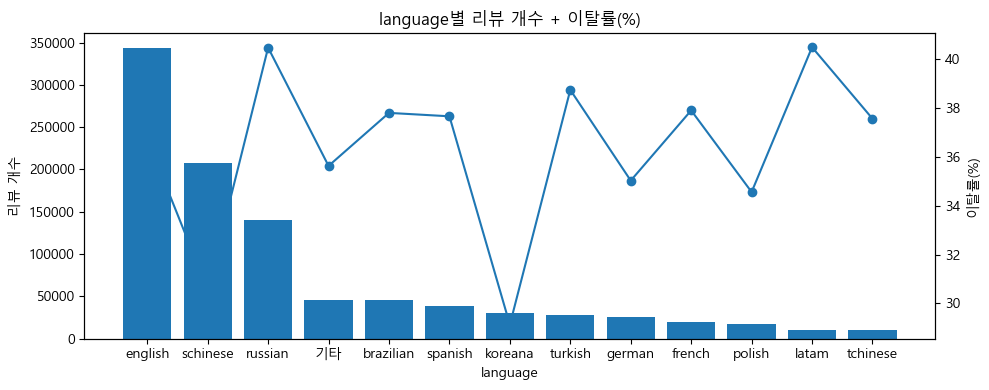

,개수,이탈률,이탈률퍼센트
language,,,
english,343693,0.367357,36.74
schinese,207802,0.305632,30.56
russian,140486,0.404781,40.48
기타,45258,0.356335,35.63
brazilian,45108,0.378048,37.80
spanish,38075,0.376651,37.67
koreana,29828,0.291303,29.13
turkish,28309,0.387474,38.75
german,25746,0.350307,35.03


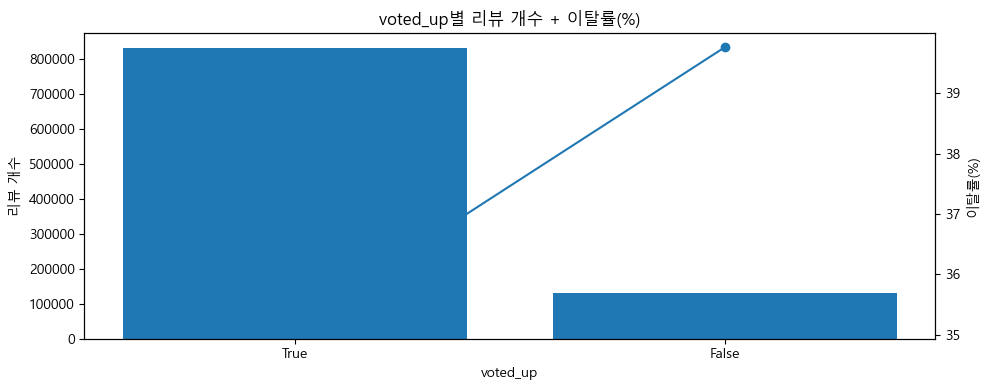

,개수,이탈률,이탈률퍼센트
voted_up,,,
True,830387,0.351669,35.17
False,130720,0.397583,39.76


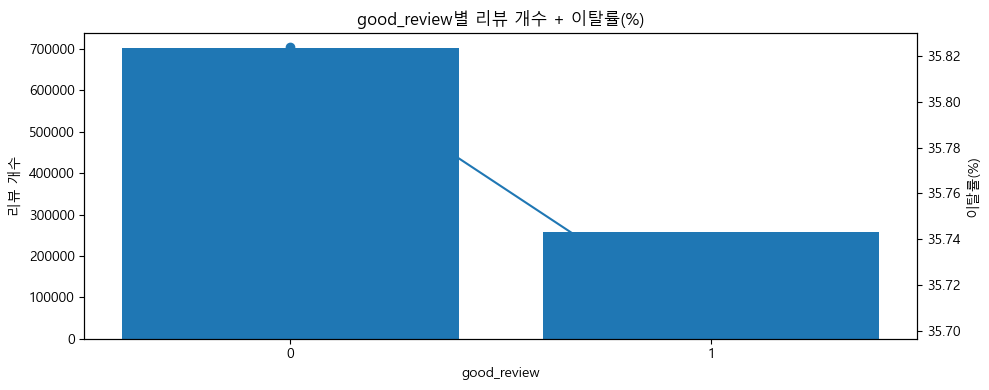

,개수,이탈률,이탈률퍼센트
good_review,,,
0,702778,0.358240,35.82
1,258329,0.357025,35.70


In [91]:
# 후보 컬럼들(데이터셋마다 이름이 다를 수 있어서 여러 후보를 넣어둠)
candidate_category = [
    "language",
    "voted_up",         # True/False인 경우 많음
    "good_review"
]

for c in candidate_category:
    if c in df_model.columns:
        category_count_churn(df_model, c, top_n=12)


교차 이탈률(%)


good_review,긍정리뷰X,긍정리뷰O
is_ending_genre,,
클리어형 아님,34.05,31.85
클리어형(추정),37.50,39.02


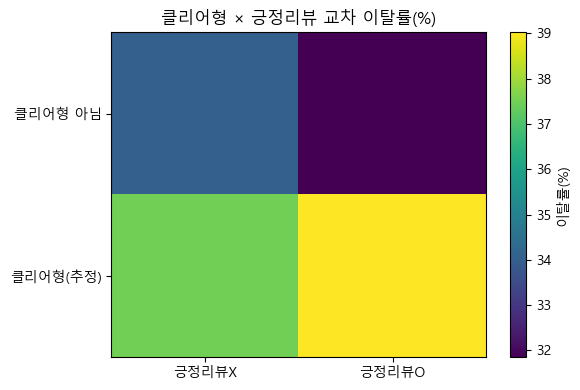

In [92]:
if ("is_ending_genre" in df_model.columns) and ("good_review" in df_model.columns):
    pivot = df_model.pivot_table(
        values="churn",
        index="is_ending_genre",
        columns="good_review",
        aggfunc="mean"
    ) * 100

    pivot.index = pivot.index.map({0:"클리어형 아님", 1:"클리어형(추정)"})
    pivot.columns = pivot.columns.map({0:"긍정리뷰X", 1:"긍정리뷰O"})

    print("교차 이탈률(%)")
    display(pivot.round(2))

    plt.figure(figsize=(6, 4))
    plt.imshow(pivot.values, aspect="auto")
    plt.colorbar(label="이탈률(%)")
    plt.xticks(range(pivot.shape[1]), pivot.columns)
    plt.yticks(range(pivot.shape[0]), pivot.index)
    plt.title("클리어형 × 긍정리뷰 교차 이탈률(%)")
    plt.tight_layout()
    plt.show()


In [107]:
# 플레이 시간 관련 컬럼들이 말도 안되는 초헤비 유저 > 봇사용 의심 + 영향력 
# 1) 상위 99.9% 캡 
cap = df["playtime_forever"].quantile(0.999)

# 2) 캡 + log1p 처리해서 바로 덮어쓰기
cap = df_model["playtime_forever"].quantile(0.999)
df_model["playtime_forever"] = np.log1p(df_model["playtime_forever"].clip(upper=cap))

# 플레이 시간은 누수가 있어서 피쳐로는 사용 안하지만 플레이시간을 제거함으로써 다른 시간 이상치를 같이 처리 해주었다

# num_games_owned
# median: 0
# 75%: 51
# max: 33,700
# std: 197
cap = df_model["num_games_owned"].quantile(0.999)
df_model["num_games_owned"] = np.log1p(df_model["num_games_owned"].clip(upper=cap))
# num_reviews_author
# median: 3
# 75%: 8
# max: 19,748
cap = df_model["num_reviews_author"].quantile(0.999)
df_model["num_reviews_author"] = np.log1p(df_model["num_reviews_author"].clip(upper=cap))

In [108]:
df_model["num_games_owned"].head()

0    1.429846
1    0.000000
2    0.000000
3    1.692090
4    0.000000
Name: num_games_owned, dtype: float64

- appid로 그룹핑

In [109]:
gb = df_model.groupby("appid")   # 한 번만 만들어두기

# g_730 = gb.get_group(730)        # 필요할 때마다 호출
# g_570 = gb.get_group(570)
# g_730.head()

In [110]:
def check_metrics(model, model_name, X_train, X_test, y_train, y_test, fit=True):
    if fit:
        model.fit(X_train, y_train)

    y_pred_train = model.predict(X_train)
    y_pred_test  = model.predict(X_test)

    print(f"\nModel: {model_name}")

    print(f"훈련 데이터 정확도 : {accuracy_score(y_train, y_pred_train):.6f}")
    print(f"훈련 데이터 정밀도 : {precision_score(y_train, y_pred_train, zero_division=0):.6f}")
    print(f"훈련 데이터 재현율 : {recall_score(y_train, y_pred_train, zero_division=0):.6f}")
    print(f"훈련 데이터 F1-Score : {f1_score(y_train, y_pred_train, zero_division=0):.6f}")

    print(f"\n테스트 데이터 정확도 : {accuracy_score(y_test, y_pred_test):.6f}")
    print(f"테스트 데이터 정밀도 : {precision_score(y_test, y_pred_test, zero_division=0):.6f}")
    print(f"테스트 데이터 재현율 : {recall_score(y_test, y_pred_test, zero_division=0):.6f}")
    print(f"테스트 데이터 F1-Score : {f1_score(y_test, y_pred_test, zero_division=0):.6f}")


In [97]:
TARGET = "churn"

# 누수 가능성이 큰 컬럼명 키워드(리뷰 시점 이후/미래정보 느낌)
# - churn을 만드는 데 직접 쓰인 시간/로그성 변수들은 제외
UNSAFE_KEYWORDS = [
    "last_played", "days_after_review",
    "timestamp", "updated",
    "playtime_forever",
    "last_two_weeks",
    "deck_playtime",
    "after_review",
    "churn_thr",
    "churn_",           # churn_30 같은 파생 타깃/누수 가능
    "appid_1",
    'playtime_last_two_weeks',
    'playtime_at_review',

    # 파생변수에 사용된 컬럼 추가
    'num_games_owned'
]

# ID 계열(의미 거의 없거나 과적합 위험)
ID_COLS = ["appid", "steamid", "recommendationid"]

def is_unsafe_col(col: str) -> bool:
    c = col.lower()
    if col in ID_COLS:
        return True
    for k in UNSAFE_KEYWORDS:
        if k in c:
            return True
    return False

# 숫자형 후보
num_cols = df_model.select_dtypes(include=[np.number]).columns.tolist()

# SAFE 후보 = (숫자형) - (타겟) - (UNSAFE/ID)
SAFE_CANDIDATES = [c for c in num_cols if (c != TARGET) and (not is_unsafe_col(c))]

print("SAFE 후보 피처 개수:", len(SAFE_CANDIDATES))
print("SAFE 후보 예시:", SAFE_CANDIDATES[:30])


SAFE 후보 피처 개수: 22
SAFE 후보 예시: ['num_reviews_author', 'votes_up', 'votes_funny', 'weighted_vote_score', 'comment_count', 'is_ending_genre', 'good_review', 'playtime_per_game', 'reviews_per_game', 'is_short_play', 'is_long_play', 'is_mid_play', 'is_heavy_user', 'positive_but_short_play', 'negative_but_long_play', 'has_votes', 'has_comment', 'ending_short_play', 'no_recent_play', 'play_drop_ratio', 'recent_ratio', 'play_intensity']


In [111]:
def select_top_features_by_corr(gdf, candidates, target="churn", top_k=12, min_var=1e-12):
    cols = [c for c in candidates if c in gdf.columns]

    # 상수/거의 상수 제거
    cols = [c for c in cols if (gdf[c].var() is not None and gdf[c].var() > min_var)]
    if len(cols) == 0:
        return []

    corr = gdf[cols + [target]].corr(numeric_only=True)[target].drop(target).dropna()
    if len(corr) == 0:
        return []

    return corr.abs().sort_values(ascending=False).head(top_k).index.tolist()


In [112]:
TOP_N_APPS = 30

top_appids = (
    df_model.groupby("appid")
    .size()
    .sort_values(ascending=False)
    .head(TOP_N_APPS)
    .index
    .tolist()
)

print("상위 30개 appid 준비 완료:", len(top_appids))


상위 30개 appid 준비 완료: 29


In [113]:
# 파라미터
MIN_ROWS = 500   # 게임별 최소 리뷰 수
TOP_K = 12       # 게임별 상관 기반 선택 피처 수

# 전처리
preprocess = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="constant", fill_value=0)),
    ("scaler", StandardScaler()),
])

# 모델 후보
model_candidates = [
    ("로지스틱회귀", LogisticRegression(max_iter=1000, class_weight="balanced", random_state=42)),
    ("랜덤포레스트", RandomForestClassifier(
        n_estimators=500, random_state=42, max_depth=5, max_leaf_nodes= 15,class_weight="balanced"
    )),
    ("히스토그래디언트부스팅", HistGradientBoostingClassifier(random_state=42)),
]


In [114]:
from sklearn.metrics import f1_score, precision_score, recall_score
import numpy as np
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier


# helper: threshold 튜닝
def best_threshold_by_f1(proba, y_true, grid=None):
    if grid is None:
        grid = np.linspace(0.05, 0.95, 91)

    best_thr = 0.5
    best_f1 = -1
    best_pre = 0
    best_rec = 0

    for thr in grid:
        pred = (proba >= thr).astype(int)
        f1 = f1_score(y_true, pred, zero_division=0)
        if f1 > best_f1:
            best_f1 = f1
            best_thr = thr
            best_pre = precision_score(y_true, pred, zero_division=0)
            best_rec = recall_score(y_true, pred, zero_division=0)

    return best_thr, best_f1, best_pre, best_rec



# 전처리 2개로 분리 (LR vs Tree)
preprocess_lr = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="constant", fill_value=0)),
    ("scaler", StandardScaler()),
])

preprocess_tree = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="constant", fill_value=0)),
])


# 최종 학습 루프 (style → top appids → best model by test_f1)
TARGET = "churn"

TOP_N_APPS = 30
MIN_ROWS  = 500
VERBOSE   = False

all_results = []

for style in ["online", "video", "story"]:
    df_s = df_model[df_model["game_style"] == style].copy()

    top_appids = (
        df_s.groupby("appid").size()
        .sort_values(ascending=False)
        .head(TOP_N_APPS)
        .index.tolist()
    )

    gb = df_s.groupby("appid")

    for appid in top_appids:
        gdf = gb.get_group(appid)

        if len(gdf) < MIN_ROWS:
            continue
        if gdf[TARGET].nunique() < 2:
            continue

        selected = [c for c in SAFE_CANDIDATES if c in gdf.columns]
        selected = [c for c in selected if gdf[c].nunique(dropna=False) > 1]
        if len(selected) == 0:
            continue

        X = gdf[selected].copy()
        y = gdf[TARGET].astype(int).copy()

        X_train, X_test, y_train, y_test = train_test_split(
            X, y, test_size=0.2, random_state=42, stratify=y
        )

        pos_rate = float(y_train.mean())  # 게임별 이탈률(학습셋 기준)

        best_row = None

        # 모델 후보를 여기서 "게임별로" 다시 구성 (class_weight 자동 전환 포함)
        cw = "balanced" if pos_rate < 0.5 else None

        local_models = [
            ("로지스틱회귀", LogisticRegression(max_iter=2000, class_weight=cw, random_state=42)),
            ("랜덤포레스트", RandomForestClassifier(
                n_estimators=400, random_state=42, n_jobs=-1,
                class_weight=cw, min_samples_leaf=10
            )),
            ("히스토그래디언트부스팅", HistGradientBoostingClassifier(random_state=42)),
        ]

        for model_name, base_clf in local_models:
            # 모델별 전처리 선택
            prep = preprocess_lr if model_name == "로지스틱회귀" else preprocess_tree

            pipe = Pipeline([("prep", prep), ("clf", base_clf)])
            pipe.fit(X_train, y_train)

            # threshold 튜닝을 위해 proba 사용 (가능한 모델만)
            if hasattr(pipe.named_steps["clf"], "predict_proba"):
                proba = pipe.predict_proba(X_test)[:, 1]
                best_thr, best_f1, best_pre, best_rec = best_threshold_by_f1(proba, y_test)
                pred_test = (proba >= best_thr).astype(int)
            else:
                # 혹시 predict_proba 없는 모델 대비 (대부분은 있음)
                pred_test = pipe.predict(X_test)
                best_thr = 0.5
                best_f1 = f1_score(y_test, pred_test, zero_division=0)
                best_pre = precision_score(y_test, pred_test, zero_division=0)
                best_rec = recall_score(y_test, pred_test, zero_division=0)

            row = {
                "game_style": style,
                "appid": appid,
                "리뷰수": int(len(gdf)),
                "이탈률(%)": round(float(y.mean()) * 100, 2),
                "피처수": int(len(selected)),
                "모델": model_name,
                "best_thr": round(float(best_thr), 3),
                "test_precision": round(float(best_pre), 6),
                "test_recall": round(float(best_rec), 6),
                "test_f1": round(float(best_f1), 6),
                "선택피처": selected,
            }

            if (best_row is None) or (row["test_f1"] > best_row["test_f1"]):
                best_row = row

        if best_row is not None:
            all_results.append(best_row)

results_df = (
    pd.DataFrame(all_results)
      .sort_values(["game_style", "test_f1"], ascending=[True, False])
      .reset_index(drop=True)
)

print("총 저장된 rows:", len(results_df))
results_df.head(20)


총 저장된 rows: 29


,game_style,appid,리뷰수,이탈률(%),피처수,모델,best_thr,test_precision,test_recall,test_f1,선택피처
0,online,3241660,82289,60.54,19,랜덤포레스트,0.36,0.879083,0.969691,0.922167,"[num_reviews_author, votes_up, votes_funny, we..."
1,online,1966720,14988,46.96,20,히스토그래디언트부스팅,0.30,0.634318,0.960938,0.764191,"[num_reviews_author, votes_up, votes_funny, we..."
2,online,1172470,34733,29.02,20,히스토그래디언트부스팅,0.30,0.537873,0.975694,0.693460,"[num_reviews_author, votes_up, votes_funny, we..."
3,online,236390,69195,22.13,19,랜덤포레스트,0.52,0.528333,0.931440,0.674229,"[num_reviews_author, votes_up, votes_funny, we..."
4,online,2139460,25674,32.87,20,랜덤포레스트,0.48,0.538517,0.882109,0.668763,"[num_reviews_author, votes_up, votes_funny, we..."
5,online,578080,91048,20.65,20,히스토그래디언트부스팅,0.31,0.495888,0.897899,0.638918,"[num_reviews_author, votes_up, votes_funny, we..."
6,online,1973530,22532,10.47,19,랜덤포레스트,0.75,0.504870,0.658898,0.571691,"[num_reviews_author, votes_up, votes_funny, we..."
7,online,381210,61177,16.50,19,히스토그래디언트부스팅,0.28,0.397645,0.786422,0.528208,"[num_reviews_author, votes_up, votes_funny, we..."
8,story,2001120,24248,77.90,20,랜덤포레스트,0.41,0.839395,0.983589,0.905789,"[num_reviews_author, votes_up, votes_funny, we..."
9,story,1426210,21887,62.35,20,랜덤포레스트,0.44,0.731068,0.930037,0.818636,"[num_reviews_author, votes_up, votes_funny, we..."


recall : 대부분 0.90 ~ 0.98으로 높은 수준을 유지함  
precision : 0.39 ~ 0.87까지 분포 되어있으며 recall에비해 상대적으로 낮음  
f1_score : 0.65 ~ 0.92로 높은 수준을 유지함

In [115]:
# style별 요약: 최고 F1 상위 10개씩
display(
    results_df.groupby("game_style")
              .head(10)
              .reset_index(drop=True)
)


,game_style,appid,리뷰수,이탈률(%),피처수,모델,best_thr,test_precision,test_recall,test_f1,선택피처
0,online,3241660,82289,60.54,19,랜덤포레스트,0.36,0.879083,0.969691,0.922167,"[num_reviews_author, votes_up, votes_funny, we..."
1,online,1966720,14988,46.96,20,히스토그래디언트부스팅,0.30,0.634318,0.960938,0.764191,"[num_reviews_author, votes_up, votes_funny, we..."
2,online,1172470,34733,29.02,20,히스토그래디언트부스팅,0.30,0.537873,0.975694,0.693460,"[num_reviews_author, votes_up, votes_funny, we..."
3,online,236390,69195,22.13,19,랜덤포레스트,0.52,0.528333,0.931440,0.674229,"[num_reviews_author, votes_up, votes_funny, we..."
4,online,2139460,25674,32.87,20,랜덤포레스트,0.48,0.538517,0.882109,0.668763,"[num_reviews_author, votes_up, votes_funny, we..."
5,online,578080,91048,20.65,20,히스토그래디언트부스팅,0.31,0.495888,0.897899,0.638918,"[num_reviews_author, votes_up, votes_funny, we..."
6,online,1973530,22532,10.47,19,랜덤포레스트,0.75,0.504870,0.658898,0.571691,"[num_reviews_author, votes_up, votes_funny, we..."
7,online,381210,61177,16.50,19,히스토그래디언트부스팅,0.28,0.397645,0.786422,0.528208,"[num_reviews_author, votes_up, votes_funny, we..."
8,story,2001120,24248,77.90,20,랜덤포레스트,0.41,0.839395,0.983589,0.905789,"[num_reviews_author, votes_up, votes_funny, we..."
9,story,1426210,21887,62.35,20,랜덤포레스트,0.44,0.731068,0.930037,0.818636,"[num_reviews_author, votes_up, votes_funny, we..."


In [116]:
# Baseline(F1) 비교: '항상 1로 예측' vs 모델 ===
# - churn 비율(p)을 그대로 쓰면, 항상 1 예측의 F1은 2p/(1+p)
# - 이 값보다 모델이 얼마나 나아졌는지(gain_over_all_1)로 "진짜 학습 성과"를 확인

tmp = results_df.copy()

p = (tmp["이탈률(%)"] / 100.0).clip(0, 1)

tmp["baseline_f1_all_1"] = (2 * p / (1 + p)).round(6)   # always predict 1
tmp["baseline_f1_majority"] = np.where(p >= 0.5, tmp["baseline_f1_all_1"], 0.0).round(6)  # majority-class F1(positive)

tmp["gain_over_all_1"] = (tmp["test_f1"] - tmp["baseline_f1_all_1"]).round(6)
tmp["gain_over_majority"] = (tmp["test_f1"] - tmp["baseline_f1_majority"]).round(6)

display(
    tmp.sort_values(["gain_over_all_1", "test_f1"], ascending=[False, False])
       .reset_index(drop=True)
       .head(30)
)

# 원본에도 붙여두기(후속 분석/저장용)
results_df = tmp

,game_style,appid,리뷰수,이탈률(%),피처수,모델,best_thr,test_precision,test_recall,test_f1,선택피처,baseline_f1_all_1,baseline_f1_majority,gain_over_all_1,gain_over_majority
0,online,1973530,22532,10.47,19,랜덤포레스트,0.75,0.504870,0.658898,0.571691,"[num_reviews_author, votes_up, votes_funny, we...",0.189554,0.000000,0.382137,0.571691
1,video,2246340,17396,32.52,20,히스토그래디언트부스팅,0.37,0.725298,0.914311,0.808910,"[num_reviews_author, votes_up, votes_funny, we...",0.490794,0.000000,0.318116,0.808910
2,online,236390,69195,22.13,19,랜덤포레스트,0.52,0.528333,0.931440,0.674229,"[num_reviews_author, votes_up, votes_funny, we...",0.362401,0.000000,0.311828,0.674229
3,online,578080,91048,20.65,20,히스토그래디언트부스팅,0.31,0.495888,0.897899,0.638918,"[num_reviews_author, votes_up, votes_funny, we...",0.342312,0.000000,0.296606,0.638918
4,video,1142710,16602,29.89,19,랜덤포레스트,0.58,0.596525,0.933535,0.727915,"[num_reviews_author, votes_up, votes_funny, we...",0.460236,0.000000,0.267679,0.727915
5,video,1086940,18398,41.96,20,랜덤포레스트,0.43,0.771413,0.933290,0.844666,"[num_reviews_author, votes_up, votes_funny, we...",0.591152,0.000000,0.253514,0.844666
6,video,1551360,28193,25.87,20,랜덤포레스트,0.39,0.503561,0.969157,0.662761,"[num_reviews_author, votes_up, votes_funny, we...",0.411059,0.000000,0.251702,0.662761
7,online,381210,61177,16.50,19,히스토그래디언트부스팅,0.28,0.397645,0.786422,0.528208,"[num_reviews_author, votes_up, votes_funny, we...",0.283262,0.000000,0.244946,0.528208
8,online,1172470,34733,29.02,20,히스토그래디언트부스팅,0.30,0.537873,0.975694,0.693460,"[num_reviews_author, votes_up, votes_funny, we...",0.449853,0.000000,0.243607,0.693460
9,video,1771300,18099,40.97,20,랜덤포레스트,0.42,0.758797,0.901551,0.824037,"[num_reviews_author, votes_up, votes_funny, we...",0.581258,0.000000,0.242779,0.824037


In [117]:
skip_log = []

gb = df_model.groupby("appid")

for appid in top_appids:
    gdf = gb.get_group(appid)

    if len(gdf) < MIN_ROWS:
        skip_log.append((appid, "MIN_ROWS 미달", len(gdf)))
        continue

    if gdf[TARGET].nunique() < 2:
        skip_log.append((appid, "타깃 단일값(0만/1만)", len(gdf)))
        continue

    selected = select_top_features_by_corr(gdf, SAFE_CANDIDATES, target=TARGET, top_k=TOP_K)
    if len(selected) < 3:
        skip_log.append((appid, f"선택 피처 부족({len(selected)})", len(gdf)))
        continue

print("스킵된 게임 수:", len(skip_log))
skip_log[:10]  # 처음 몇 개만 보기


스킵된 게임 수: 0


[]

In [118]:
import re

def has_unsafe_keyword(col):
    c = col.lower()
    for k in UNSAFE_KEYWORDS:
        if k in c:
            return True
    return False

# results_df["선택피처"]가 list 형태라고 가정
bad_rows = []
for i, row in results_df.iterrows():
    feats = row["선택피처"]
    bad = [f for f in feats if has_unsafe_keyword(f)]
    if bad:
        bad_rows.append((row["appid"], bad))

bad_rows[:10], len(bad_rows)


([], 0)

In [119]:
from sklearn.metrics import confusion_matrix, classification_report, f1_score, balanced_accuracy_score

# results_df = pd.DataFrame(results)

def eval_best_model_for_appid(appid):
    row = results_df[results_df["appid"] == appid].iloc[0]
    best_model_name = row["모델"]
    feats = row["선택피처"]

    gdf = df_model[df_model["appid"] == appid].copy()
    X = gdf[feats].copy()
    y = gdf[TARGET].astype(int).copy()

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42, stratify=y
    )

    # model_candidates에서 best 모델 찾기
    name2clf = {n: c for n, c in model_candidates}
    base_clf = name2clf[best_model_name]

    pipe = Pipeline([("prep", preprocess), ("clf", base_clf)])
    pipe.fit(X_train, y_train)

    pred = pipe.predict(X_test)

    print("appid =", appid)
    print("best_model =", best_model_name)
    print("churn_rate(test) =", y_test.mean())
    print("pred_positive_rate =", pred.mean())  # 예측이 얼마나 1로 쏠리는지

    print("\nconfusion_matrix")
    print(confusion_matrix(y_test, pred))

    print("\nreport")
    print(classification_report(y_test, pred, digits=4))

    print("f1(pos=1) =", f1_score(y_test, pred, pos_label=1))
    print("f1(pos=0) =", f1_score(y_test, pred, pos_label=0))
    print("macro_f1 =", f1_score(y_test, pred, average="macro"))
    print("balanced_acc =", balanced_accuracy_score(y_test, pred))

# 예시
eval_best_model_for_appid(1771300)


appid = 1771300
best_model = 랜덤포레스트
churn_rate(test) = 0.40966850828729284
pred_positive_rate = 0.47292817679558014

confusion_matrix
[[1718  419]
 [ 190 1293]]

report
              precision    recall  f1-score   support

           0     0.9004    0.8039    0.8494      2137
           1     0.7553    0.8719    0.8094      1483

    accuracy                         0.8318      3620
   macro avg     0.8278    0.8379    0.8294      3620
weighted avg     0.8410    0.8318    0.8330      3620

f1(pos=1) = 0.8093896713615023
f1(pos=0) = 0.8494437577255871
macro_f1 = 0.8294167145435447
balanced_acc = 0.8379060328395028


In [120]:


skip = Counter()
skip_detail = []

for appid in top_appids:
    gdf = df_model[df_model["appid"] == appid].copy()

    if len(gdf) < MIN_ROWS:
        skip["MIN_ROWS"] += 1
        skip_detail.append((appid, "MIN_ROWS", len(gdf), gdf[TARGET].nunique()))
        continue

    if gdf[TARGET].nunique() < 2:
        skip["ONE_CLASS"] += 1
        skip_detail.append((appid, "ONE_CLASS", len(gdf), gdf[TARGET].nunique()))
        continue

    selected = [c for c in SAFE_CANDIDATES if c in gdf.columns]
    selected = [c for c in selected if gdf[c].nunique(dropna=False) > 1]

    if len(selected) < 1:  
        skip["NO_FEATURE"] += 1
        skip_detail.append((appid, "NO_FEATURE", len(gdf), gdf[TARGET].nunique()))
        continue

print("스킵 요약:", skip)
print("스킵 상세(앞 20개):", skip_detail[:20])


스킵 요약: Counter()
스킵 상세(앞 20개): []
